# NORMALLİK TESTLERİ

Hipotez testlerine başlamadan önce, verilerinizin hangi test türüne uygun olduğunu belirlemek için normallik testlerini yapmamız gerekir."a"

## 1. SHAPIRO–WILK Testi

**Ne İçin Kullanılır?**</br>
Bir örneklemin, Normal Dağılımdan gelip gelmediğini test etmek için kullanılır. Özellikle küçük örneklem büyüklüklerinde (n<50) en güçlü normallik testi olarak kabul edilir.</br>

**Kısa Anlatım**</br>

Gözlem değerlerini beklenen Normal dağılım değerleriyle karşılaştırır. H0​ hipotezi, verinin Normal dağılıma sahip olduğunu varsayar. Eğer p-değeri anlamlılık düzeyi (α) altında ise, H0​ reddedilir ve verinin Normal dağılmadığı sonucuna varılır.</br>




In [1]:
import numpy as np
from scipy import stats

# 🧪 Senaryo: Küçük bir veri setinin (n=30) normalliğini test edelim
np.random.seed(15)
veri_seti = np.random.normal(loc=10, scale=2, size=30) # Normal dağılımdan üretilen veri

# Shapiro-Wilk Testi Uygulanması
shapiro_istatistik, p_degeri = stats.shapiro(veri_seti)

print(f"Shapiro-Wilk İstatistiği: {shapiro_istatistik:.3f}")
print(f"P Değeri: {p_degeri:.5f}")

# Hipotez Karar Mekanizması (α = 0.05)
if p_degeri < 0.05:
    print("\nSonuç: P değeri < 0.05. H0 reddedilir. Veri, Normal dağılım göstermez.")
else:
    print("\nSonuç: P değeri ≥ 0.05. H0 reddedilemez. Veri, Normal dağılım gösterir (Parametrik testler kullanılabilir).")

Shapiro-Wilk İstatistiği: 0.974
P Değeri: 0.64062

Sonuç: P değeri ≥ 0.05. H0 reddedilemez. Veri, Normal dağılım gösterir (Parametrik testler kullanılabilir).


## 2. Kolmogorov-Smirnov / Lilliefors Testi (veya Large Sample Testleri)</br>

Lilliefors testi, Kolmogorov-Smirnov testiyle aynı hesaplamaları kullanır, ancak Kolmogorov-Smirnov Tablosu yerine Lilliefors Test Tablosu'ndaki kritik değerler tablosu kullanılır. Bu tablodaki kritik değerler daha küçük olduğundan, Lilliefors Testi'nin verilerin normal dağılım gösterdiğini gösterme olasılığı daha düşüktür.

**Ne İçin Kullanılır?**</br>
Verilerin teorik bir dağılıma uygunluğunu test eder. Genellikle büyük örneklem büyüklüklerinde (n≥50) normalliği test etmek için kullanılır.</br>

**Kısa Anlatım**</br>
Ampirik Dağılım Fonksiyonu (EDF) ile beklenen teorik dağılım fonksiyonu arasındaki en büyük mutlak farkı ölçer. H0​ hipotezi, verinin teorik dağılıma uygun olduğunu varsayar. (Eğer testte ortalama ve standart sapma veriden tahmin ediliyorsa, buna Lilliefors Testi denir).</br>


In [5]:
import numpy as np
from scipy import stats

# 🧪 Senaryo: Büyük bir veri setinin (n=100) normalliğini test edelim
np.random.seed(15)
veri_seti_b = np.random.lognormal(mean=2, sigma=0.5, size=100) # Log-Normal (Çarpık) dağılımdan üretilen veri

# Kolmogorov-Smirnov Testi Uygulanması (Normal dağılıma karşı test)
# loc ve scale parametrelerini girmediğimizde varsayımları veriden tahmin eder (Lilliefors testi gibi çalışır)
ks_istatistik, p_degeri = stats.kstest(veri_seti_b, 'norm', args=(veri_seti_b.mean(), veri_seti_b.std()))

print(f"KS İstatistiği: {ks_istatistik:.3f}")
print(f"P Değeri: {p_degeri:.5f}")

if p_degeri < 0.05:
    print("\nSonuç: P değeri < 0.05. H0 reddedilir. Veri, Normal dağılım göstermez.")
else:
    print("\nSonuç: P değeri ≥ 0.05. H0 reddedilemez. Veri, Normal dağılım gösterir.")

KS İstatistiği: 0.157
P Değeri: 0.01262

Sonuç: P değeri < 0.05. H0 reddedilir. Veri, Normal dağılım göstermez.


In [7]:
## ⚙️ Kolmogorov-Smirnov Testi (Belirlenen Parametrelerle Uygulama)

# Kullanım Amacı: Veri setinin, ORTALAMASI (loc) ve STANDART SAPMASI (scale) 
# DIŞARIDAN BELİRLENMİŞ (tahmin edilmemiş) teorik bir Normal dağılıma ne kadar uyduğunu test eder.

# Hipotez:
# H0: Veri, belirlenen N(loc, scale) dağılımından gelmektedir.
# H1: Veri, belirlenen N(loc, scale) dağılımından gelmemektedir.

# --- Gerçek Dünya Verisi Senaryosu: Bir cihazın 100 ölçümü ---
np.random.seed(8)

# Cihazın nominal olarak μ=50, σ=5 değerlerinde ölçüm yapması bekleniyor.
# Veri, bu beklenen dağılımdan üretiliyor.
beklenen_ortalama = 50 
beklenen_std = 5
veri_olcum = np.random.normal(loc=beklenen_ortalama, scale=beklenen_std, size=100)


### A. Kolmogorov-Smirnov (KS) Testi Uygulaması

# KSTest'i uygularken, beklenen parametreleri 'args' içine tuple olarak geçiriyoruz: 
# args=(loc, scale)
ks_stat, ks_p = stats.kstest(
    veri_olcum, 
    stats.norm.cdf, 
    args=(beklenen_ortalama, beklenen_std)
)

print(f"Beklenen Ortalama (loc): {beklenen_ortalama:.2f}")
print(f"Beklenen Standart Sapma (scale): {beklenen_std:.2f}")
print(f"Gerçek Veri Ortalaması: {veri_olcum.mean():.2f}")
print(f"Gerçek Veri Std. Sapması: {veri_olcum.std():.2f}")
print("-" * 50)
print(f"KS İstatistiği: {ks_stat:.3f}")
print(f"P Değeri: {ks_p:.5f}")

# Hipotez Karar Mekanizması (α = 0.05)
if ks_p < 0.05:
    print("\nSonuç: P değeri < 0.05. H0 Reddedildi. Veri, belirlenen Normal dağılımı temsil etmiyor.")
else:
    print("\nSonuç: P değeri ≥ 0.05. H0 Kabul Edildi. Veri, belirlenen Normal dağılımı istatistiksel olarak temsil etmektedir. ✅")

Beklenen Ortalama (loc): 50.00
Beklenen Standart Sapma (scale): 5.00
Gerçek Veri Ortalaması: 50.31
Gerçek Veri Std. Sapması: 5.63
--------------------------------------------------
KS İstatistiği: 0.079
P Değeri: 0.53855

Sonuç: P değeri ≥ 0.05. H0 Kabul Edildi. Veri, belirlenen Normal dağılımı istatistiksel olarak temsil etmektedir. ✅


## 3. Anderson-Darling (A-D) Testi </br>
Akademik çalışmalarda normallik kontrolü için Shapiro-Wilk ve Kolmogorov-Smirnov testlerinin yanı sıra sıkça kullanılan bir diğer güçlü araç Anderson-Darling (A-D) Testi'dir.</br>

**Testin Amacı**</br>
Bir örneklemin, belirli bir dağılımdan (en sık Normal Dağılım) gelip gelmediğini test etmek için kullanılır.</br>

**Kısa Anlatım**</br>
Kolmogorov-Smirnov Testi'nin (KS) geliştirilmiş bir versiyonudur. KS testi, ampirik (gözlenen) dağılım fonksiyonu ile teorik (beklenen) dağılım fonksiyonu arasındaki maksimum farkı ölçerken; A-D testi, bu farkı, kuyruklara (uç noktalara) daha fazla ağırlık vererek ölçer. Bu sayede, özellikle dağılımın kuyruk bölgelerindeki sapmalara karşı daha hassas sonuçlar üretir.</br>

**Hipotezler**</br>
<ul>
    <li>H0​: Veri, beklenen dağılımdan gelmektedir (örneğin Normal dağılım).</li>
    <li>H1​: Veri, beklenen dağılımdan gelmemektedir.</li>
</ul>

**Ne Zaman Kullanılır?**<br>
<ul>
    <li><b>Kuyruk Hassasiyeti İhtiyacı:</b> Dağılımın uç noktalarındaki (kuyruklarındaki) aykırı değerlerin veya sapmaların normallik test sonucunu etkilemesi istendiğinde kullanılır. Bu, finansal veriler, mühendislik toleransları veya ekstrem olayların incelendiği alanlar için önemlidir.
    </li>
    <li><b>Alternatif Dağılımları Test Etme:</b> A-D testi, sadece Normal dağılımı değil, aynı zamanda Log-Normal, Weibull, Gamma gibi diğer belirli dağılımların uygunluğunu test etmek için de yaygın olarak kullanılır.
    </li>
    <li><b>Shapiro-Wilk Alternatifi:</b> Genellikle Shapiro-Wilk testi, küçük örneklemler için en güçlü test kabul edilirken, A-D testi de hem küçük hem de orta büyüklükteki örneklemler için oldukça güçlü bir alternatiftir.
    </li>
    
</ul>



In [11]:
import numpy as np
from scipy import stats

# --- Gerçek Dünya Verisi Senaryosu: Makine Öğrenmesi Modelinin Hata Dağılımı ---
np.random.seed(50)

# 1. Normal Dağılım Gösteren Hata (Model hatasının normal dağılması beklenir)
hata_normal = np.random.normal(loc=0, scale=1.5, size=60) 

# 2. Kuyrukları Ağır Dağılım (Örneğin, bazı büyük aykırı hatalar var)
# t dağılımı, normal dağılıma göre daha ağır kuyrukludur
hata_kuyruk_agir = stats.t.rvs(df=3, loc=0, scale=1.5, size=60)


### A. Normal Dağılım İçin Anderson-Darling Testi Uygulaması

# Parametre 'dist="norm"' olarak ayarlanırsa, testin normal dağılıma karşı yapıldığı belirtilir.
ad_result_normal = stats.anderson(hata_normal, dist='norm')

print("--- Normal Dağılan Veri İçin A-D Sonuçları ---")
print(f"Anderson-Darling İstatistiği: {ad_result_normal.statistic:.3f}")
print("Kritik Değerler (Alpha Düzeyleri ile):")
print(pd.DataFrame({'Kritik Değer': ad_result_normal.critical_values, 
                    'Anlamlılık Düzeyi (Alpha)': ad_result_normal.significance_level}))

# Yorumlama Kuralı:
# Elde edilen A-D İstatistiği, herhangi bir Kritik Değerden büyükse H0 reddedilir.

# En yaygın kullanılan %5 (0.05) anlamlılık düzeyi için kritik değeri alalım:
kritik_deger_05 = ad_result_normal.critical_values[2] 

if ad_result_normal.statistic > kritik_deger_05:
    print("\nSonuç: A-D İstatistiği Kritik Değerden BÜYÜK. H0 Reddedildi. Veri Normal dağılmaz. ❌")
else:
    print("\nSonuç: A-D İstatistiği Kritik Değerden KÜÇÜK. H0 Reddedilemedi. Veri Normal dağılır. ✅")

--- Normal Dağılan Veri İçin A-D Sonuçları ---
Anderson-Darling İstatistiği: 0.359
Kritik Değerler (Alpha Düzeyleri ile):
   Kritik Değer  Anlamlılık Düzeyi (Alpha)
0         0.544                       15.0
1         0.619                       10.0
2         0.743                        5.0
3         0.866                        2.5
4         1.030                        1.0

Sonuç: A-D İstatistiği Kritik Değerden KÜÇÜK. H0 Kabul Edildi. Veri Normal dağılır. ✅


In [13]:
### B. Kuyrukları Ağır Dağılım İçin A-D Testi Uygulaması

ad_result_agir = stats.anderson(hata_kuyruk_agir, dist='norm')

print("\n--- Kuyrukları Ağır Veri İçin A-D Sonuçları ---")
print(f"Anderson-Darling İstatistiği: {ad_result_agir.statistic:.3f}")

# %5 (0.05) anlamlılık düzeyi için kritik değeri tekrar alalım:
kritik_deger_05_agir = ad_result_agir.critical_values[2] 

if ad_result_agir.statistic > kritik_deger_05_agir:
    print("\nSonuç: A-D İstatistiği Kritik Değerden BÜYÜK. H0 Reddedildi. Veri Normal dağılmaz. ❌")
    print("Yorum: A-D testi, kuyruklardaki sapmaları algılamakta başarılı oldu.")
else:
    print("\nSonuç: A-D İstatistiği Kritik Değerden KÜÇÜK. H0 Reddedilemedi. Veri Normal dağılır. ✅")


--- Kuyrukları Ağır Veri İçin A-D Sonuçları ---
Anderson-Darling İstatistiği: 1.046

Sonuç: A-D İstatistiği Kritik Değerden BÜYÜK. H0 Reddedildi. Veri Normal dağılmaz. ❌
Yorum: A-D testi, kuyruklardaki sapmaları algılamakta başarılı oldu.


## Q-Q Grafiği (Quantile-Quantile Plot)</br>

**Tanım**</br>

Bir kantil-kantil grafiği olarak bilinen Q-Q Grafiği, bir veri örneğinin dağılımını, karşılaştırma yapılan teorik bir dağılımın (genellikle Normal Dağılım) kantilleriyle görsel olarak karşılaştıran bir grafiktir.</br>

**Eksenler**</br>
Y Ekseni: Veri setinizdeki sıralanmış gözlem değerleri (Ampirik Kantiller).</br>
X Ekseni: Beklenen teorik dağılımdan (örneğin Normal dağılım) gelen aynı kantil değerleri.</br>

**Amacı**</br>
İstatistiksel varsayımların, özellikle Normallik Varsayımının grafiksel olarak hızlıca doğrulanmasını sağlamaktır. Normallik testlerinin (Shapiro-Wilk, KS, A-D) sonucunu görsel olarak desteklemek ve sapmanın hangi bölgelerde (orta veya kuyruklar) olduğunu anlamak için kritik öneme sahiptir.</br>

**Ne Zaman Kullanılır?**</br>

Q-Q Grafiği, genellikle istatistiksel analizlerin başlangıç aşamalarında, özellikle parametrik testlere (T-Testi, ANOVA) geçmeden hemen önce, normallik varsayımını görselleştirmek için kullanılır.</br>

<ul>
    <li><b>Normallik Varsayımını Kontrol Etme:</b> Bir istatistiksel testin (örneğin T-Testi) ön koşulu olarak verinin Normal dağılıma uygun olup olmadığını görmek için.
    </li>
    <li><b>Dağılımın Şeklini Anlama:</b> İstatistiksel testlerin (A-D, Shapiro-Wilk) sadece bir p-değeri verdiği durumda, Q-Q grafiği size dağılımın neden Normal olmadığını (çarpık mı, basık mı, kuyrukları mı ağır?) gösterir.
    </li>
    <li><b>Aykırı Değerleri Tespit Etme:</b> Grafiğin uç noktalarından (kuyruklarından) çok uzaklaşan noktalar, veri setindeki aykırı değerlere (outliers) işaret edebilir.
    </li>
</ul>

**Grafiğin Yorumlanması**</br>
<ul>
    <li><b>Mükemmel Uyum:</b> Veri noktalarının tamamı, grafikteki 45 derecelik düz referans çizgisine yakın bir şekilde diziliyorsa, veri seti Normal dağılım göstermektedir.
    </li>
    <li><b>Kuyruk Sapması (Basıklık/Kurtosis):</b> Noktalar düz çizgiyi takip eder, ancak uçlarda (kuyruklarda) çizgiden saparak yukarı veya aşağı kıvrılırsa, dağılımın ağır kuyruklu (leptokurtik) veya hafif kuyruklu (platykurtik) olduğu anlaşılır.
    </li>
    <li><b>Eğrilik (Çarpıklık/Skewness):</b> Noktalar S-şeklinde bir eğri oluşturuyorsa, bu verinin çarpık (skewed) olduğunu gösterir.
    </li>
</ul>

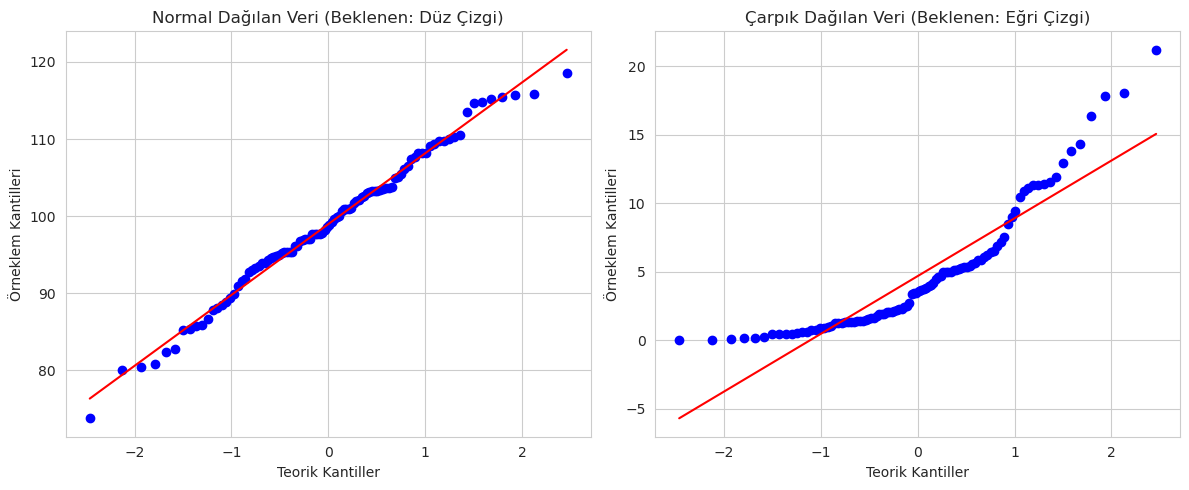

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

# --- Veri Setleri ---
np.random.seed(42)

# 1. Normal Dağılan Veri (Q-Q grafiğinde düz çizgi beklenir)
veri_normal = np.random.normal(loc=100, scale=10, size=100) 

# 2. Çarpık Dağılan Veri (Q-Q grafiğinde eğrilik beklenir)
veri_carpik = np.random.exponential(scale=5, size=100)

### A. Normal Dağılan Veri İçin Q-Q Grafiği

plt.figure(figsize=(12, 5))

# Sol Grafiği (Normal Veri)
plt.subplot(1, 2, 1)
stats.probplot(veri_normal, dist="norm", plot=plt)
plt.title("Normal Dağılan Veri (Beklenen: Düz Çizgi)")
plt.xlabel("Teorik Kantiller")
plt.ylabel("Örneklem Kantilleri")
 # Bu kısım görsel olarak düz bir çizgiye benzeyecektir.

# Sağ Grafiği (Çarpık Veri)
plt.subplot(1, 2, 2)
stats.probplot(veri_carpik, dist="norm", plot=plt)
plt.title("Çarpık Dağılan Veri (Beklenen: Eğri Çizgi)")
plt.xlabel("Teorik Kantiller")
plt.ylabel("Örneklem Kantilleri")
 # Üstel dağılım, sadece sağa çarpık (right-skewed) olduğu için, Q-Q grafiğinde S-şekli yerine, 
 # genellikle tek yöne doğru eğri bir yay (bir bumerangı andıran bir eğrilik) oluşturur.

 # S-şekli, genellikle dağılımın hem basıklık hem de çarpıklık açısından Normal dağılımdan saptığı 
 # veya kuyruklarının düzensiz olduğu durumlarda daha belirgin olarak görülür.

plt.tight_layout()
plt.show()

Basıklık Değeri (Excess Kurtosis): -1.165
Sonuç: Dağılım basıktır (Platykurtic).


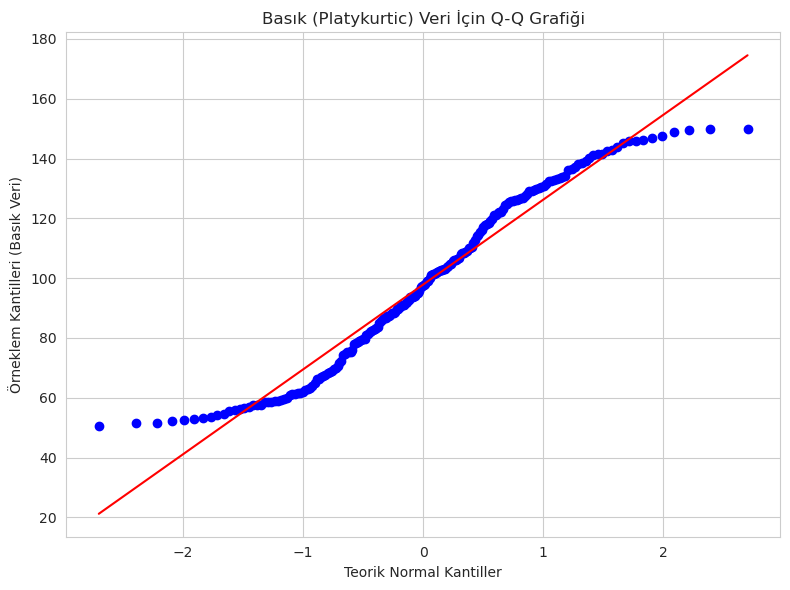

In [17]:
## 📉 Basık (Platykurtic) Veri İçin Q-Q Grafiği Uygulaması

# Amaç: Basık bir dağılımın, Normal dağılımın varsayımsal düz çizgisine karşı 
# nasıl bir sapma gösterdiğini görselleştirmek.

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd

np.random.seed(25)

# --- Veri Seti: Basık Dağılım ---
# Uniform dağılım, Normal dağılıma göre basık (platykurtic) bir dağılımdır.
# Kuyrukları çok hafiftir ve merkezi çok düzdür.
veri_basik = np.random.uniform(low=50, high=150, size=200)


### A. Dağılımın Basıklık Değerini Kontrol Etme (Excess Kurtosis)

# Normal dağılım için bu değer ~0 olmalıdır.
# Basık dağılımlar için bu değer < 0 olacaktır.
excess_kurtosis = stats.kurtosis(veri_basik)

print(f"Basıklık Değeri (Excess Kurtosis): {excess_kurtosis:.3f}")
if excess_kurtosis < 0:
    print("Sonuç: Dağılım basıktır (Platykurtic).")
else:
    print("Sonuç: Dağılım sivri veya normaldir.")


### B. Basık Veri İçin Q-Q Grafiği Oluşturma

plt.figure(figsize=(8, 6))

# Q-Q Grafiği (Normal dağılıma karşı)
stats.probplot(veri_basik, dist="norm", plot=plt)
plt.title("Basık (Platykurtic) Veri İçin Q-Q Grafiği")
plt.xlabel("Teorik Normal Kantiller")
plt.ylabel("Örneklem Kantilleri (Basık Veri)")


plt.tight_layout()
plt.show()

Sağa Çarpıklık Değeri: 1.427


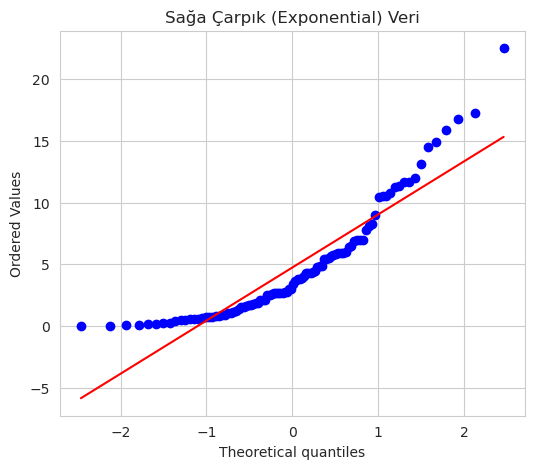

In [19]:
# 1. Sağa Çarpık (Pozitif Çarpık) Veri
# Bu durumda veriler sol tarafa yığılmıştır ve sağ kuyruk uzundur (Örn: Gelir dağılımı).

# Görsel Deseni,Yorum
# Alt Kuyruk:,Noktalar referans çizgisinin altında kalır.
# Üst Kuyruk:,Noktalar referans çizgisinin üzerine çıkarak uzaklaşır.
# Grafik Şekli:,"Başlangıçta yavaş yükselir, sonra hızlanır (Yayvan bir kase gibi)."

# --- Sağa Çarpık Veri (Üstel Dağılım) ---
np.random.seed(1)
veri_saga_carpik = np.random.exponential(scale=5, size=100) 
print(f"Sağa Çarpıklık Değeri: {stats.skew(veri_saga_carpik):.3f}")

plt.figure(figsize=(6, 5))
stats.probplot(veri_saga_carpik, dist="norm", plot=plt)
plt.title("Sağa Çarpık (Exponential) Veri")
plt.show()


Sola Çarpıklık Değeri: -1.427


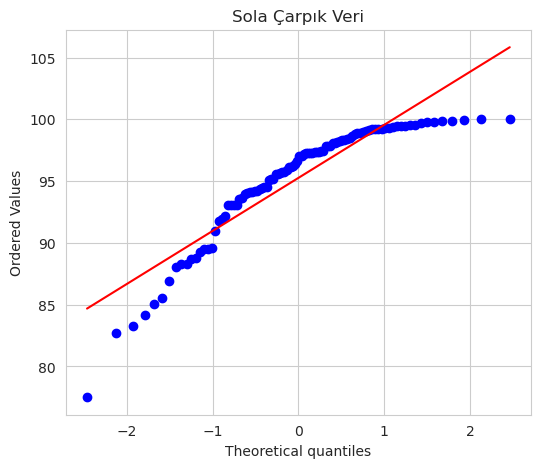

In [20]:
# 2.  Sola Çarpık (Negatif Çarpık) Veri
# Bu durumda veriler sağ tarafa yığılmıştır ve sol kuyruk uzundur (Örn: Çok kolay bir sınavın not dağılımı).

# Görsel Deseni,Yorum
# Alt Kuyruk:,Noktalar referans çizgisinin üzerine çıkarak uzaklaşır.
# Üst Kuyruk:,Noktalar referans çizgisinin altında kalır.
# Grafik Şekli:,"Başlangıçta hızla yükselir, sonra yavaşlar (Ters bir kase gibi)."

# --- Sola Çarpık Veri (Sağa çarpık veriyi ters çevirerek elde edilir) ---
np.random.seed(1)
# 100 sayısından çıkararak sola çarpık hale getiriyoruz
veri_sola_carpik = 100 - np.random.exponential(scale=5, size=100) 
print(f"Sola Çarpıklık Değeri: {stats.skew(veri_sola_carpik):.3f}")

plt.figure(figsize=(6, 5))
stats.probplot(veri_sola_carpik, dist="norm", plot=plt)
plt.title("Sola Çarpık Veri")
plt.show()

## Varyansların Homojenliği (Eşitliği) Kontrolü - Levene Testi</br>

**Neden Gerekli?**</br>
T-Testi ve ANOVA gibi Parametrik testler, karşılaştırılan grupların popülasyon varyanslarının istatistiksel olarak eşit olduğunu varsayar. Eğer varyanslar çok farklı ise (heterojen), testin sonuçları (özellikle p-değeri) güvenilirliğini kaybedebilir.</br>

**Kullanım Amacı**</br>
İki veya daha fazla grubun varyanslarının (veya standart sapmalarının) istatistiksel olarak eşit olup olmadığını test etmek için kullanılır. </br>

**Hipotez:**</br>
<ul>
    <li>H0 (Null Hipotezi): Grupların popülasyon varyansları eşittir (Homojen). (p > 0.05 ise kabul edilir)</li>
    <li>H1 (Alternatif Hipotez): En az bir grubun popülasyon varyansı diğerlerinden farklıdır (Heterojen). (p < 0.05 ise H0 reddedilir)</li>
</ul>



In [9]:
import numpy as np
from scipy import stats
# --- Gerçek Dünya Verisi Senaryosu: İki farklı yatırım stratejisinin getirileri ---
np.random.seed(20)

# Strateji 1: Düşük Risk (Küçük Varyans)
getiri_risk_dusuk = np.random.normal(loc=10, scale=3, size=40) 

# Strateji 2: Yüksek Risk (Büyük Varyans)
getiri_risk_yuksek = np.random.normal(loc=12, scale=10, size=40)

### B. Levene Testi Uygulaması

# center='median' (varsayılan) kullanmak, verinin Normal dağılmadığı durumlarda 
# daha sağlam (robust) sonuçlar verir (Brown-Forsythe Testi'ne yakındır).
levene_stat, levene_p = stats.levene(getiri_risk_dusuk, getiri_risk_yuksek, center='median')

print(f"Grup 1 Varyansı: {getiri_risk_dusuk.var():.2f}")
print(f"Grup 2 Varyansı: {getiri_risk_yuksek.var():.2f}")
print("-" * 50)
print(f"Levene İstatistiği: {levene_stat:.3f}")
print(f"P Değeri: {levene_p:.5f}")

# Hipotez Karar Mekanizması (α = 0.05)
if levene_p < 0.05:
    print("\nSonuç: P değeri < 0.05. H0 Reddedildi. Grupların varyansları ANLAMLI OLARAK FARKLI (Heterojen). ❌")
    print("Not: Bu durumda T-Testi yapılırken 'equal_var=False' (Welch's T-Test) kullanılmalıdır.")
else:
    print("\nSonuç: P değeri ≥ 0.05. H0 Kabul Edildi. Grupların varyansları EŞİT (Homojen). ✅")
    print("Not: Bu durumda T-Testi yapılırken 'equal_var=True' kullanılabilir.")

Grup 1 Varyansı: 11.53
Grup 2 Varyansı: 95.96
--------------------------------------------------
Levene İstatistiği: 25.379
P Değeri: 0.00000

Sonuç: P değeri < 0.05. H0 Reddedildi. Grupların varyansları ANLAMLI OLARAK FARKLI (Heterojen). ❌
Not: Bu durumda T-Testi yapılırken 'equal_var=False' (Welch's T-Test) kullanılmalıdır.


## HİPOTEZ TESTLERİNİN PARAMETRİK VE NON-PARMAETRİK KARŞILIKLARI

## A. İki Bağımsız Grup Karşılaştırması

<!DOCTYPE html>
<html>
<head>
    <style>
        table {
            border-collapse: collapse;
            width: 100%;
            margin: 20px 0;
        }
        th, td {
            border: 1px solid #ddd;
            padding: 8px;
            text-align: left;
        }
        th {
            background-color: #f2f2f2;
            font-weight: bold;
        }
        tr:nth-child(even) {
            background-color: #f9f9f9;
        }
    </style>
</head>
<body>
    <table>
        <thead>
            <tr>
                <th>Kriter</th>
                <th>Parametrik Test</th>
                <th>Non-Parametrik Karşılığı</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>Normallik</td>
                <td>Sağlanıyor</td>
                <td>İhlal Ediliyor veya Veri Sıralı</td>
            </tr>
            <tr>
                <td>Test Adı</td>
                <td>Bağımsız İki Örneklem T-Testi</td>
                <td>Mann-Whitney U Testi</td>
            </tr>
        </tbody>
    </table>
</body>
</html>


<!DOCTYPE html>
<html>
<head>
    <style>
        table {
            border-collapse: collapse;
            width: 100%;
            margin: 20px 0;
        }
        th, td {
            border: 1px solid #ddd;
            padding: 8px;
            text-align: left;
        }
        th {
            background-color: #f2f2f2;
            font-weight: bold;
        }
        tr:nth-child(even) {
            background-color: #f9f9f9;
        }
        .math {
            font-style: italic;
        }
    </style>
</head>
<body>
    <table>
        <thead>
            <tr>
                <th>İçerik</th>
                <th>Bağımsız T-Testi (Parametrik)</th>
                <th>Mann-Whitney U Testi (Non-Parametrik)</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>Amaç</td>
                <td>İki grubun Ortalamalarında fark var mı?</td>
                <td>İki grubun Medyanlarında/Dağılımlarında fark var mı?</td>
            </tr>
            <tr>
                <td>H<sub>0</sub></td>
                <td>μ<sub>1</sub> = μ<sub>2</sub></td>
                <td>P(X > Y) = P(Y > X) (Bir gruptaki değerlerin diğerinden büyük olma olasılığı 0.5'tir)</td>
            </tr>
            <tr>
                <td>Python Örnek</td>
                <td>scipy.stats.ttest_ind(grup1, grup2)</td>
                <td>scipy.stats.mannwhitneyu(grup1, grup2)</td>
            </tr>
        </tbody>
    </table>
</body>
</html>

In [21]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(5)

### A. Parametrik Durum Uygulaması: Bağımsız İki Örneklem T-Testi

# Koşul: Gruplar Normal Dağılım Göstermelidir.

# 🧪 Veri Oluşturma: Normal Dağılıma Uygun İlaç Etki Süreleri (Ortalamalarda Fark Var)
# Bu verilerin normal dağıldığını varsayıyoruz.
ilac_a_normal = np.random.normal(loc=120, scale=15, size=40) 
ilac_b_normal = np.random.normal(loc=135, scale=15, size=40) # Yeni ilaç daha etkili bekleniyor

# 1. Normallik Kontrolü (Gözlemlemek İçin)
# Her iki grubun da p > 0.05 vermesi beklenir
shapiro_a_p = stats.shapiro(ilac_a_normal).pvalue
shapiro_b_p = stats.shapiro(ilac_b_normal).pvalue

print(f"Grup A Shapiro p-değeri: {shapiro_a_p:.3f} ({'Normal' if shapiro_a_p >= 0.05 else 'Normal Değil'})")
print(f"Grup B Shapiro p-değeri: {shapiro_b_p:.3f} ({'Normal' if shapiro_b_p >= 0.05 else 'Normal Değil'})")
print("-" * 50)

# 2. T-Testi Uygulaması
# Varsayım sağlandığı için T-Testi kullanılır.
# equal_var=True/False kararı için Levene testi yapılmalıdır, burada True varsayalım.
t_stat, t_p = stats.ttest_ind(ilac_a_normal, ilac_b_normal, equal_var=True) 

print(f"Grup A Ortalama Etki: {ilac_a_normal.mean():.2f}")
print(f"Grup B Ortalama Etki: {ilac_b_normal.mean():.2f}")
print("-" * 50)
print(f"T İstatistiği: {t_stat:.3f}")
print(f"P Değeri: {t_p:.5f}")

if t_p < 0.05:
    print("\nSonuç: P değeri < 0.05. Grupların ORTALAMALARI arasında ANLAMLI FARK VARDIR.")
    print("Yorum: Yeni ilaç (Grup B) istatistiksel olarak daha uzun süre etkilidir (H0 reddedilir).")
else:
    print("\nSonuç: P değeri ≥ 0.05. Grupların ortalamaları arasında ANLAMLI FARK YOKTUR.")

Grup A Shapiro p-değeri: 0.439 (Normal)
Grup B Shapiro p-değeri: 0.796 (Normal)
--------------------------------------------------
Grup A Ortalama Etki: 120.90
Grup B Ortalama Etki: 136.12
--------------------------------------------------
T İstatistiği: -4.668
P Değeri: 0.00001

Sonuç: P değeri < 0.05. Grupların ORTALAMALARI arasında ANLAMLI FARK VARDIR.
Yorum: Yeni ilaç (Grup B) istatistiksel olarak daha uzun süre etkilidir (H0 reddedilir).


In [24]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(5)

# --- Non-Parametrik Durum Uygulaması: Mann-Whitney U Testi ---

# Koşul: Gruplar Normal Dağılım Varsayımını KESİNLİKLE İhlal Ediyor.

# 🧪 Düzeltilmiş Veri Oluşturma: Normal Dağılmayan (Şiddetli Çarpık) Etki Süreleri
# Exponential Distribution (Üstel Dağılım) kullanılarak üretilmiştir.
ilac_a_carpik_duzeltme = np.random.exponential(scale=50, size=40) 
ilac_b_carpik_duzeltme = np.random.exponential(scale=65, size=40) # Yeni ilaç daha uzun ortalama etkiye sahip

# 1. Normallik Kontrolü (Gözlemlemek ve İhlali Kanıtlamak İçin)
shapiro_a_p_d = stats.shapiro(ilac_a_carpik_duzeltme).pvalue
shapiro_b_p_d = stats.shapiro(ilac_b_carpik_duzeltme).pvalue

print("--- Normallik Kontrolü ---")
print(f"Grup A Shapiro p-değeri: {shapiro_a_p_d:.5f} ({'Normal' if shapiro_a_p_d >= 0.05 else 'Normal Değil'})")
print(f"Grup B Shapiro p-değeri: {shapiro_b_p_d:.5f} ({'Normal' if shapiro_b_p_d >= 0.05 else 'Normal Değil'})")

# Gözlem: Her iki p-değerinin de 0.05'ten küçük, yani H0'ın reddedilmesi beklenir.
print("\nSonuç: Normallik varsayımı ihlal edildi. Non-Parametrik test kullanılmalıdır.")
print("-" * 50)

# 2. Mann-Whitney U Testi Uygulaması
u_stat, u_p = stats.mannwhitneyu(ilac_a_carpik_duzeltme, ilac_b_carpik_duzeltme, alternative='two-sided')

print("--- Mann-Whitney U Test Sonuçları ---")
print(f"Grup A Medyan Etki: {np.median(ilac_a_carpik_duzeltme):.2f}")
print(f"Grup B Medyan Etki: {np.median(ilac_b_carpik_duzeltme):.2f}")
print("-" * 50)
print(f"Mann-Whitney U İstatistiği: {u_stat:.3f}")
print(f"P Değeri: {u_p:.5f}")

if u_p < 0.05:
    print("\nSonuç: P değeri < 0.05. Grupların MEDYANLARI/DAĞILIMLARI arasında ANLAMLI FARK VARDIR. ✅")
    print("Yorum: Non-Parametrik analize göre, Yeni ilaç (Grup B) daha etkilidir.")
else:
    print("\nSonuç: P değeri ≥ 0.05. Grupların medyanları/dağılımları arasında ANLAMLI FARK YOKTUR. ❌")

--- Normallik Kontrolü ---
Grup A Shapiro p-değeri: 0.00000 (Normal Değil)
Grup B Shapiro p-değeri: 0.00138 (Normal Değil)

Sonuç: Normallik varsayımı ihlal edildi. Non-Parametrik test kullanılmalıdır.
--------------------------------------------------
--- Mann-Whitney U Test Sonuçları ---
Grup A Medyan Etki: 27.92
Grup B Medyan Etki: 52.83
--------------------------------------------------
Mann-Whitney U İstatistiği: 587.000
P Değeri: 0.04088

Sonuç: P değeri < 0.05. Grupların MEDYANLARI/DAĞILIMLARI arasında ANLAMLI FARK VARDIR. ✅
Yorum: Non-Parametrik analize göre, Yeni ilaç (Grup B) daha etkilidir.


In [25]:
# Sıralı Veri İle Mann-Whitney U Testi

import numpy as np
from scipy import stats

# --- Senaryo: İki Ürünün Müşteri Memnuniyeti Anketi (1-5 Likert Ölçeği) ---
# 1: Kesinlikle Katılmıyorum (Çok Memnuniyetsiz)
# 5: Kesinlikle Katılıyorum (Çok Memnun)

np.random.seed(123)

# Ürün 1: Biraz daha düşük ve değişken memnuniyet
urun_1_memnuniyet = np.array([3, 4, 2, 3, 3, 5, 2, 4, 3, 3, 2, 1, 4, 3, 3, 2, 4, 3, 3, 3, 4, 2, 3, 3, 5])
# Ürün 2: Daha yüksek memnuniyet beklentisi
urun_2_memnuniyet = np.array([4, 5, 4, 4, 5, 4, 5, 5, 4, 4, 3, 5, 4, 4, 5, 4, 5, 5, 4, 4, 5, 4, 5, 4, 5])

# Sıralı veri olduğu için T-Testi yerine doğrudan Mann-Whitney U Testi kullanılır.
# Normallik kontrolüne GEREK YOKTUR.

# 1. Mann-Whitney U Testi Uygulaması
u_stat, u_p = stats.mannwhitneyu(urun_1_memnuniyet, urun_2_memnuniyet, alternative='two-sided')

print("--- Sıralı Veri Karşılaştırması (Likert) ---")
print(f"Ürün 1 Medyan Memnuniyet: {np.median(urun_1_memnuniyet):.2f}")
print(f"Ürün 2 Medyan Memnuniyet: {np.median(urun_2_memnuniyet):.2f}")
print("-" * 50)
print(f"Mann-Whitney U İstatistiği: {u_stat:.3f}")
print(f"P Değeri: {u_p:.5f}")

if u_p < 0.05:
    print("\nSonuç: P değeri < 0.05. İki ürünün memnuniyet DAĞILIMLARI arasında anlamlı fark vardır.")
    print("Yorum: Ürün 2, istatistiksel olarak daha yüksek sıralı memnuniyete sahiptir.")
else:
    print("\nSonuç: P değeri ≥ 0.05. İki ürünün memnuniyet dağılımları arasında anlamlı fark yoktur.")

--- Sıralı Veri Karşılaştırması (Likert) ---
Ürün 1 Medyan Memnuniyet: 3.00
Ürün 2 Medyan Memnuniyet: 4.00
--------------------------------------------------
Mann-Whitney U İstatistiği: 82.500
P Değeri: 0.00000

Sonuç: P değeri < 0.05. İki ürünün memnuniyet DAĞILIMLARI arasında anlamlı fark vardır.
Yorum: Ürün 2, istatistiksel olarak daha yüksek sıralı memnuniyete sahiptir.


## İki Bağımlı Grup Karşılaştırması

<!DOCTYPE html>
<html>
<head>
    <style>
        table {
            border-collapse: collapse;
            width: 100%;
            margin: 20px 0;
        }
        th, td {
            border: 1px solid #ddd;
            padding: 8px;
            text-align: left;
        }
        th {
            background-color: #f2f2f2;
            font-weight: bold;
        }
        tr:nth-child(even) {
            background-color: #f9f9f9;
        }
    </style>
</head>
<body>
    <table>
        <thead>
            <tr>
                <th>Kriter</th>
                <th>Parametrik Test</th>
                <th>Non-Parametrik Karşılığı</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>Normallik</td>
                <td>Sağlanıyor (Farkların dağılımı)</td>
                <td>İhlal Ediliyor veya Veri Sıralı</td>
            </tr>
            <tr>
                <td>Test Adı</td>
                <td>Bağımlı (Eşleştirilmiş) Örneklem T-Testi</td>
                <td>Wilcoxon İşaretli Sıralar Testi</td>
            </tr>
        </tbody>
    </table>
</body>
</html>

html
<!DOCTYPE html>
<html>
<head>
    <style>
        table {
            border-collapse: collapse;
            width: 100%;
            margin: 20px 0;
        }
        th, td {
            border: 1px solid #ddd;
            padding: 8px;
            text-align: left;
        }
        th {
            background-color: #f2f2f2;
            font-weight: bold;
        }
        tr:nth-child(even) {
            background-color: #f9f9f9;
        }
    </style>
</head>
<body>
    <table>
        <thead>
            <tr>
                <th>İçerik</th>
                <th>Bağımlı T-Testi (Parametrik)</th>
                <th>Wilcoxon İşaretli Sıralar Testi (Non-Parametrik)</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>Amaç</td>
                <td>Aynı bireylerin iki farklı zamandaki (önce/sonra) ortalamaları arasında fark var mı?</td>
                <td>Aynı bireylerin iki farklı zamandaki medyanlarında/dağılımlarında fark var mı?</td>
            </tr>
            <tr>
                <td>H<sub>0</sub></td>
                <td>μ<sub>fark</sub> = 0</td>
                <td>Medyan farkının sıfır olduğu.</td>
            </tr>
            <tr>
                <td>Python Örnek</td>
                <td>scipy.stats.ttest_rel(oncesi, sonrasi)</td>
                <td>scipy.stats.wilcoxon(oncesi, sonrasi)</td>
            </tr>
        </tbody>
    </table>
</body>
</html>

Senaryo: Öğrenci Hız Okuma Programının Etkisi

Grup: 25 öğrenciden oluşan tek bir grup.

Koşullar:

Önce: Hız okuma programından önceki okuma hızı (kelime/dakika).

Sonra: Programdan sonraki okuma hızı (kelime/dakika).
Hipotez: Programın okuma hızını artırması beklenmektedir.

In [26]:
import numpy as np
from scipy import stats
import pandas as pd

np.random.seed(30) 
N = 25 # Örneklem büyüklüğü

In [27]:
# 1. Parametrik Durum: Eşleştirilmiş Örneklem T-Testi
# Koşul: Eşleştirilmiş gözlemler arasındaki farklar Normal dağılıma uymalıdır.

# 🧪 Veri Oluşturma: Farklar Normal Dağılıma Uygun
# Farkların ortalaması 15 kelime/dakika olacak şekilde normal dağılım yaratıyoruz.
fark_normal = np.random.normal(loc=15, scale=5, size=N)

# "Önce" skorları
okuma_hizi_once = np.random.normal(loc=250, scale=20, size=N) 
# "Sonra" skorları: Önceki skorlar + Normal dağılan fark
okuma_hizi_sonra = okuma_hizi_once + fark_normal 

# FARK verilerinin Normallik Kontrolü (T-Testi için ana koşul)
shapiro_fark_p = stats.shapiro(fark_normal).pvalue

print(f"Farklar Grubu Shapiro p-değeri: {shapiro_fark_p:.3f} ({'Normal' if shapiro_fark_p >= 0.05 else 'Normal Değil'})")
print("-" * 70)

if shapiro_fark_p >= 0.05:
    print("Koşul: Farklar Normal dağılıyor. Parametrik T-Testi kullanılabilir. ✅")
    
    # Eşleştirilmiş T-Testi Uygulaması (ttest_rel)
    t_stat, t_p = stats.ttest_rel(okuma_hizi_once, okuma_hizi_sonra) 

    print(f"\nÖnce Ortalama: {okuma_hizi_once.mean():.2f}")
    print(f"Sonra Ortalama: {okuma_hizi_sonra.mean():.2f}")
    print(f"T İstatistiği: {t_stat:.3f}")
    print(f"P Değeri: {t_p:.5f}")

    if t_p < 0.05:
        print("\nSonuç: P < 0.05. Programın etkisi istatistiksel olarak ANLAMLI ve olumludur (H0 reddedildi).")
    else:
        print("\nSonuç: P ≥ 0.05. Programın etkisi anlamlı DEĞİLDİR.")
else:
    print("Koşul: Farklar Normal dağılmıyor. Non-Parametrik test kullanılmalıdır.")

Farklar Grubu Shapiro p-değeri: 0.583 (Normal)
----------------------------------------------------------------------
Koşul: Farklar Normal dağılıyor. Parametrik T-Testi kullanılabilir. ✅

Önce Ortalama: 248.83
Sonra Ortalama: 263.33
T İstatistiği: -12.290
P Değeri: 0.00000

Sonuç: P < 0.05. Programın etkisi istatistiksel olarak ANLAMLI ve olumludur (H0 reddedildi).


In [28]:
# 2. Non-Parametrik Durum: Wilcoxon İşaretli Sıra Testi

# Veri Oluşturma: Farklar Normal Dağılıma UYGUN DEĞİL (Çarpık Dağılım)
# Farkların üstel dağılmasını (şiddetli çarpık) sağlayarak normal dağılımı ihlal ediyoruz.
fark_carpik = np.random.exponential(scale=15, size=N)

# "Önce" skorları
hiz_once_carpik = np.random.normal(loc=250, scale=20, size=N) 
# "Sonra" skorları: Önceki skorlar + Çarpık dağılan fark
hiz_sonra_carpik = hiz_once_carpik + fark_carpik 

# FARK verilerinin Normallik Kontrolü (İhlali Kanıtlamak İçin)
fark_carpik_array = hiz_sonra_carpik - hiz_once_carpik
shapiro_fark_p_carpik = stats.shapiro(fark_carpik_array).pvalue

print(f"Farklar Grubu Shapiro p-değeri: {shapiro_fark_p_carpik:.5f} ({'Normal' if shapiro_fark_p_carpik >= 0.05 else 'Normal Değil'})")
print("-" * 70)

if shapiro_fark_p_carpik < 0.05:
    print("Koşul: Farklar Normal dağılmıyor. Non-Parametrik Wilcoxon Testi kullanılmalıdır. ✅")
    
    # Wilcoxon İşaretli Sıra Testi Uygulaması (wilcoxon)
    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(hiz_once_carpik, hiz_sonra_carpik, alternative='two-sided')

    print(f"\nÖnce Medyan: {np.median(hiz_once_carpik):.2f}")
    print(f"Sonra Medyan: {np.median(hiz_sonra_carpik):.2f}")
    print(f"Wilcoxon İstatistiği: {wilcoxon_stat:.3f}")
    print(f"P Değeri: {wilcoxon_p:.5f}")

    if wilcoxon_p < 0.05:
        print("\nSonuç: P < 0.05. İki durumun medyan sıralamaları arasında ANLAMLI FARK VARDIR.")
        print("Yorum: Non-Parametrik analize göre, program hızı anlamlı ölçüde artırmıştır (H0 reddedildi).")
    else:
        print("\nSonuç: P ≥ 0.05. İki durumun medyan sıralamaları arasında anlamlı fark YOKTUR.")
else:
     print("Koşul: Farklar Normal dağılıyor. Parametrik T-Testi kullanılabilirdi.")

Farklar Grubu Shapiro p-değeri: 0.00008 (Normal Değil)
----------------------------------------------------------------------
Koşul: Farklar Normal dağılmıyor. Non-Parametrik Wilcoxon Testi kullanılmalıdır. ✅

Önce Medyan: 240.49
Sonra Medyan: 251.71
Wilcoxon İstatistiği: 0.000
P Değeri: 0.00000

Sonuç: P < 0.05. İki durumun medyan sıralamaları arasında ANLAMLI FARK VARDIR.
Yorum: Non-Parametrik analize göre, program hızı anlamlı ölçüde artırmıştır (H0 reddedildi).


## Üç veya Daha Fazla Bağımsız Grup Karşılaştırması


<!DOCTYPE html>
<html>
<head>
    <style>
        table {
            border-collapse: collapse;
            width: 100%;
            margin: 20px 0;
        }
        th, td {
            border: 1px solid #ddd;
            padding: 8px;
            text-align: left;
        }
        th {
            background-color: #f2f2f2;
            font-weight: bold;
        }
        tr:nth-child(even) {
            background-color: #f9f9f9;
        }
    </style>
</head>
<body>
    <table>
        <thead>
            <tr>
                <th>Kriter</th>
                <th>Parametrik Test</th>
                <th>Non-Parametrik Karşılığı</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>Normallik</td>
                <td>Sağlanıyor</td>
                <td>İhlal Ediliyor veya Veri Sıralı</td>
            </tr>
            <tr>
                <td>Test Adı</td>
                <td>Tek Yönlü ANOVA (F Testi)</td>
                <td>Kruskal-Wallis H Testi</td>
            </tr>
        </tbody>
    </table>
</body>
</html>


<!DOCTYPE html>
<html>
<head>
    <style>
        table {
            border-collapse: collapse;
            width: 100%;
            margin: 20px 0;
        }
        th, td {
            border: 1px solid #ddd;
            padding: 8px;
            text-align: left;
        }
        th {
            background-color: #f2f2f2;
            font-weight: bold;
        }
        tr:nth-child(even) {
            background-color: #f9f9f9;
        }
    </style>
</head>
<body>
    <table>
        <thead>
            <tr>
                <th>İçerik</th>
                <th>Tek Yönlü ANOVA (Parametrik)</th>
                <th>Kruskal-Wallis H Testi (Non-Parametrik)</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>Amaç</td>
                <td>Üç veya daha fazla grubun Ortalamaları arasında fark var mı?</td>
                <td>Üç veya daha fazla grubun Medyanları/Dağılımları arasında fark var mı?</td>
            </tr>
            <tr>
                <td>H<sub>0</sub></td>
                <td>μ<sub>1</sub> = μ<sub>2</sub> = μ<sub>3</sub> = ...</td>
                <td>Tüm grupların medyanları eşittir.</td>
            </tr>
            <tr>
                <td>Python Örnek</td>
                <td>scipy.stats.f_oneway(g1, g2, g3)</td>
                <td>scipy.stats.kruskal(g1, g2, g3)</td>
            </tr>
        </tbody>
    </table>
</body>
</html>


Senaryo: Üç Farklı Eğitim Metodunun Etkinliği

Gruplar: Üç farklı öğrenim metodu uygulanan üç bağımsız öğrenci grubu (Grup X, Y, Z).

Ölçüm: Yıl sonu sınav puanları.

Hipotez: Metotların öğrenci başarısı (puan ortalamaları/medyanları) üzerinde anlamlı bir fark yaratıp yaratmadığı.

In [29]:
import numpy as np
from scipy import stats
import pandas as pd

np.random.seed(45) 
N = 30 # Her gruptaki öğrenci sayısı

In [30]:
# 1. Parametrik Durum: Tek Yönlü ANOVA (F-Testi)

# Koşullar
# 1. Tüm gruplar Normal Dağılım göstermelidir.
# 2. Grupların Varyansları Eşit olmalıdır (Levene Testi).

# Veri Oluşturma: Normal Dağılıma ve Eşit Varyansta Uygun
# Ortalamalarda anlamlı fark olacak şekilde normal dağılım yaratıyoruz.
grup_x_normal = np.random.normal(loc=70, scale=8, size=N) 
grup_y_normal = np.random.normal(loc=75, scale=8, size=N)
grup_z_normal = np.random.normal(loc=85, scale=8, size=N) 

# --- Varsayım Kontrolleri ---
# 1. Normallik Kontrolü (Shapiro-Wilk)
print("--- Normallik Kontrolü (p > 0.05 beklenir) ---")
print(f"Grup X p: {stats.shapiro(grup_x_normal).pvalue:.3f}")
print(f"Grup Y p: {stats.shapiro(grup_y_normal).pvalue:.3f}")
print(f"Grup Z p: {stats.shapiro(grup_z_normal).pvalue:.3f}")

# 2. Varyans Eşitliği Kontrolü (Levene Testi)
levene_p = stats.levene(grup_x_normal, grup_y_normal, grup_z_normal).pvalue
print(f"\nLevene p-değeri: {levene_p:.3f} ({'Eşit' if levene_p >= 0.05 else 'Eşit Değil'})")
print("-" * 50)

if levene_p >= 0.05:
    print("Koşul: Normallik ve Eşit Varyanslar sağlanıyor. Tek Yönlü ANOVA kullanılabilir. ✅")
    
    # Tek Yönlü ANOVA Uygulaması (f_oneway)
    f_stat, f_p = stats.f_oneway(grup_x_normal, grup_y_normal, grup_z_normal) 

    print(f"\nOrtalamalar: X={grup_x_normal.mean():.2f}, Y={grup_y_normal.mean():.2f}, Z={grup_z_normal.mean():.2f}")
    print(f"F İstatistiği: {f_stat:.3f}")
    print(f"P Değeri: {f_p:.5f}")

    if f_p < 0.05:
        print("\nSonuç: P < 0.05. Grupların ORTALAMALARI arasında ANLAMLI FARK VARDIR (H0 reddedilir).")
        print("Yorum: En az bir eğitim metodu, diğerlerinden istatistiksel olarak farklı başarıya yol açmıştır.")
        print("Not: Hangi grupların farklı olduğunu bulmak için ek bir Post-Hoc testi (örn: Tukey HSD) yapılmalıdır.")
    else:
        print("\nSonuç: P ≥ 0.05. Grupların ortalamaları arasında anlamlı fark YOKTUR.")
else:
     print("Koşul: Varyans eşitliği ihlal edildi. Welch's ANOVA veya Kruskal-Wallis düşünülmelidir.")


--- Normallik Kontrolü (p > 0.05 beklenir) ---
Grup X p: 0.882
Grup Y p: 0.600
Grup Z p: 0.289

Levene p-değeri: 0.242 (Eşit)
--------------------------------------------------
Koşul: Normallik ve Eşit Varyanslar sağlanıyor. Tek Yönlü ANOVA kullanılabilir. ✅

Ortalamalar: X=67.29, Y=73.81, Z=86.41
F İstatistiği: 53.109
P Değeri: 0.00000

Sonuç: P < 0.05. Grupların ORTALAMALARI arasında ANLAMLI FARK VARDIR (H0 reddedilir).
Yorum: En az bir eğitim metodu, diğerlerinden istatistiksel olarak farklı başarıya yol açmıştır.
Not: Hangi grupların farklı olduğunu bulmak için ek bir Post-Hoc testi (örn: Tukey HSD) yapılmalıdır.


## Post-Hoc Analizi: Tukey HSD Testi

**Amaç:** Tek Yönlü ANOVA'nın gruplar arasında genel bir fark bulması durumunda, tüm olası grup çiftlerini sistematik olarak karşılaştırmak ve hangi spesifik çiftler arasındaki farkın istatistiksel olarak anlamlı olduğunu belirlemektir.</br>

**Hipotez:**</br>
<ul>
    <li>H0​: Karşılaştırılan iki grup ortalaması arasında fark yoktur (μi​=μj​).</li>
    <li>H1​: Karşılaştırılan iki grup ortalaması arasında fark vardır (μi​=μj​)</li>
</ul>

In [32]:
import numpy as np
import pandas as pd
from scipy import stats
# Yeni kütüphane: Post-Hoc testler için statsmodels kütüphanesinden multigroup compare modülü
from statsmodels.stats.multicomp import pairwise_tukeyhsd 

# --- 1. Veri Hazırlığı (Uzun Formata Dönüştürme) ---
# Tukey HSD için veri tek bir 'skor' sütununda ve gruplar ayrı bir 'grup' sütununda olmalıdır.

# Önceki örnekteki verileri yeniden oluşturuyoruz (seed=45):
np.random.seed(45) 
N = 30 
grup_x_normal = np.random.normal(loc=70, scale=8, size=N) 
grup_y_normal = np.random.normal(loc=75, scale=8, size=N)
grup_z_normal = np.random.normal(loc=85, scale=8, size=N) 

# Pandas DataFrame oluşturma
df = pd.DataFrame({
    'skor': np.concatenate([grup_x_normal, grup_y_normal, grup_z_normal]),
    'grup': np.repeat(['Grup X', 'Grup Y', 'Grup Z'], N)
})

print("--- Grupların Ortalama Skorları ---")
print(df.groupby('grup')['skor'].mean().round(2))
print("-" * 50)


# --- 2. Tukey HSD Testi Uygulaması ---

# tukey_hsd fonksiyonu, DataFrame'deki skorları ve grup etiketlerini alır.
tukey_results = pairwise_tukeyhsd(endog=df['skor'], groups=df['grup'], alpha=0.05)

print(tukey_results)

--- Grupların Ortalama Skorları ---
grup
Grup X    67.29
Grup Y    73.81
Grup Z    86.41
Name: skor, dtype: float64
--------------------------------------------------
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
Grup X Grup Y    6.523 0.0024 2.0268 11.0192   True
Grup X Grup Z  19.1152    0.0 14.619 23.6115   True
Grup Y Grup Z  12.5922    0.0  8.096 17.0885   True
---------------------------------------------------


**Sonuçların Yorumlanması**</br>
html
<!DOCTYPE html>
<html>
<head>
    <style>
        table {
            border-collapse: collapse;
            width: 100%;
            margin: 20px 0;
        }
        th, td {
            border: 1px solid #ddd;
            padding: 8px;
            text-align: left;
        }
        th {
            background-color: #f2f2f2;
            font-weight: bold;
        }
        tr:nth-child(even) {
            background-color: #f9f9f9;
        }
    </style>
</head>
<body>
    <table>
        <thead>
            <tr>
                <th>Alan</th>
                <th>Açıklama</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>group1, group2</td>
                <td>Karşılaştırılan grup çiftleri.</td>
            </tr>
            <tr>
                <td>meandiff</td>
                <td>İki grubun ortalamaları arasındaki fark.</td>
            </tr>
            <tr>
                <td>lower, upper</td>
                <td>Ortalamalar arasındaki fark için %95 güven aralığı.</td>
            </tr>
            <tr>
                <td>reject</td>
                <td>Hipotez kararı. True ise, ortalamalar arasında anlamlı fark vardır.</td>
            </tr>
        </tbody>
    </table>
</body>
</html>


In [31]:
# 2. Non-Parametrik Durum: Kruskal-Wallis H Testi
# Koşul: Normallik varsayımı ihlal ediliyor (en az bir grup Normal dağılmıyor) veya veriler Sıralı Ölçekte.

# 🧪 Veri Oluşturma: Normal Dağılım Varsayımını İhlal Eden Gruplar
# Grup Z'yi şiddetli sağa çarpık (Üstel dağılım) yapıyoruz.
grup_a_carpik = np.random.normal(loc=50, scale=10, size=N) 
grup_b_carpik = np.random.normal(loc=55, scale=10, size=N)
grup_c_carpik = np.random.exponential(scale=70, size=N) # Çarpık Grup (Normal değil)

# --- Varsayım Kontrolü ---
# Grup Z'nin Normalliğinin ihlal edilmesi beklenir.
print("--- Normallik Kontrolü ---")
print(f"Grup A p: {stats.shapiro(grup_a_carpik).pvalue:.3f}")
print(f"Grup B p: {stats.shapiro(grup_b_carpik).pvalue:.3f}")
print(f"Grup C p (Çarpık): {stats.shapiro(grup_c_carpik).pvalue:.5f}")
print("-" * 50)

if stats.shapiro(grup_c_carpik).pvalue < 0.05:
    print("Koşul: Normallik varsayımı ihlal edildi (Grup C). Kruskal-Wallis Testi kullanılmalıdır. ✅")
    
    # Kruskal-Wallis H Testi Uygulaması (kruskal)
    kw_h_stat, kw_h_p = stats.kruskal(grup_a_carpik, grup_b_carpik, grup_c_carpik) 

    print(f"\nMedyanlar: A={np.median(grup_a_carpik):.2f}, B={np.median(grup_b_carpik):.2f}, C={np.median(grup_c_carpik):.2f}")
    print(f"Kruskal-Wallis H İstatistiği: {kw_h_stat:.3f}")
    print(f"P Değeri: {kw_h_p:.5f}")

    if kw_h_p < 0.05:
        print("\nSonuç: P < 0.05. Grupların MEDYANLARI/DAĞILIM SIRALAMALARI arasında ANLAMLI FARK VARDIR (H0 reddedilir).")
        print("Yorum: Üç metot arasında başarı sıralaması açısından fark bulunmaktadır.")
        print("Not: Hangi grupların farklı olduğunu bulmak için ek bir Post-Hoc testi (örneğin Dunn's Testi) yapılmalıdır.")
    else:
        print("\nSonuç: P ≥ 0.05. Grupların medyanları/dağılım sıralamaları arasında anlamlı fark YOKTUR.")
else:
     print("Koşul: Normallik sağlandı. ANOVA kullanılabilir.")


--- Normallik Kontrolü ---
Grup A p: 0.982
Grup B p: 0.590
Grup C p (Çarpık): 0.00212
--------------------------------------------------
Koşul: Normallik varsayımı ihlal edildi (Grup C). Kruskal-Wallis Testi kullanılmalıdır. ✅

Medyanlar: A=46.62, B=56.80, C=69.38
Kruskal-Wallis H İstatistiği: 6.664
P Değeri: 0.03572

Sonuç: P < 0.05. Grupların MEDYANLARI/DAĞILIM SIRALAMALARI arasında ANLAMLI FARK VARDIR (H0 reddedilir).
Yorum: Üç metot arasında başarı sıralaması açısından fark bulunmaktadır.
Not: Hangi grupların farklı olduğunu bulmak için ek bir Post-Hoc testi (örneğin Dunn's Testi) yapılmalıdır.


## Non-Parametrik Post-Hoc Analizi: Bonferroni Düzeltmeli Mann-Whitney U Test

**Amaç:** Kruskal-Wallis'in bulduğu genel farkın (grupların sıralamaları/medyanları arasında) hangi spesifik grup çiftleri arasında olduğunu tespit etmek.</br>

**Yöntem:**</br>

1. Tüm olası grup çiftleri için (A-B, A-C, B-C) Mann-Whitney U testi uygulanır.
2. Elde edilen p-değerleri, Bonferroni Düzeltmesi ile çarpılır. 
    - Düzeltme Katsayısı (k): Yapılan ikili karşılaştırma sayısı. (Burada k=3).


In [37]:
import numpy as np
from scipy import stats
import pandas as pd

# Önceki Kruskal-Wallis örneğinden veriler:
np.random.seed(45) 
N = 30
grup_a_carpik = np.random.normal(loc=50, scale=10, size=N) 
grup_b_carpik = np.random.normal(loc=55, scale=10, size=N)
grup_c_carpik = np.random.exponential(scale=70, size=N) 

# İkili karşılaştırma sayısı (k=3): A-B, A-C, B-C
k = 3 
alpha = 0.05


# Tüm olası grup çiftleri için Mann-Whitney U testi yapıyoruz.

# A vs B
p_ab = stats.mannwhitneyu(grup_a_carpik, grup_b_carpik).pvalue
p_adj_ab = p_ab * k

# A vs C
p_ac = stats.mannwhitneyu(grup_a_carpik, grup_c_carpik).pvalue
p_adj_ac = p_ac * k

# B vs C
p_bc = stats.mannwhitneyu(grup_b_carpik, grup_c_carpik).pvalue
p_adj_bc = p_bc * k

# P-değerleri 1'den büyük çıkarsa 1'e yuvarlanır.
p_adj_ab = min(p_adj_ab, 1)
p_adj_ac = min(p_adj_ac, 1)
p_adj_bc = min(p_adj_bc, 1)

results = pd.DataFrame({
    'Karşılaştırma': ['Grup A vs B', 'Grup A vs C', 'Grup B vs C'],
    'Ham p-değeri': [p_ab, p_ac, p_bc],
    'Bonferroni p_adj': [p_adj_ab, p_adj_ac, p_adj_bc],
    'Anlamlı Fark (p_adj < 0.05)': [p_adj_ab < alpha, p_adj_ac < alpha, p_adj_bc < alpha]
})

print("--- Bonferroni Düzeltmeli Mann-Whitney U Testleri ---")
print(f"Düzeltme Katsayısı (k): {k}")
print(f"Anlamlılık Düzeyi (α): {alpha}")
print("-" * 70)
print(results.to_string(index=False))

# Genel Medyanları Tekrar Hatırlayalım:
medyan_a = np.median(grup_a_carpik)
medyan_b = np.median(grup_b_carpik)
medyan_c = np.median(grup_c_carpik)
print(f"\nMedyanlar: A={medyan_a:.2f}, B={medyan_b:.2f}, C={medyan_c:.2f}")

--- Bonferroni Düzeltmeli Mann-Whitney U Testleri ---
Düzeltme Katsayısı (k): 3
Anlamlılık Düzeyi (α): 0.05
----------------------------------------------------------------------
Karşılaştırma  Ham p-değeri  Bonferroni p_adj  Anlamlı Fark (p_adj < 0.05)
  Grup A vs B      0.009468          0.028405                         True
  Grup A vs C      0.153667          0.461002                        False
  Grup B vs C      0.428963          1.000000                        False

Medyanlar: A=47.00, B=52.40, C=59.48
